# ABC2Vec — Notebook 02: ABC Tokenizer & Bar Patchifier

Implements the core tokenization strategy for ABC2Vec:

1. **Character-level vocabulary** — build a vocabulary from ABC notation characters
2. **Bar Patchifier** — group characters within a single bar into a patch (following CLaMP/MelodyT5)
3. **Patch embedding** — linear projection of bar patches to embedding dimension
4. **Transposition utility** — transpose ABC tunes by semitones (for Transposition Invariance objective)
5. **Visualization** — show tokenized tunes and patch statistics

**Design choice**: Option A from the research brief — character-level with bar patching (proven in CLaMP/MelodyT5).

In [1]:
import os, re, json, collections
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

PROJECT_DIR = Path('/Volumes/LLModels/ABC2VEC')
PROCESSED_DIR = PROJECT_DIR / 'data' / 'processed'

sns.set_theme(style='whitegrid')

In [2]:
# ─── Load processed training data ───
train_df = pd.read_parquet(PROCESSED_DIR / 'train.parquet')
print(f"Loaded {len(train_df):,} training tunes")
print(f"Columns: {list(train_df.columns)}")
print(f"\nSample ABC body:")
print(train_df.iloc[0]['abc_body'][:300])

Loaded 198,893 training tunes
Columns: ['abc_clean', 'abc_body', 'abc_header', 'key', 'meter', 'tune_type', 'unit_length', 'title', 'num_bars', 'num_sections', 'char_length', 'source', 'original_idx', 'body_hash', 'root_note', 'mode', 'extracted_num_sections', 'tune_id']

Sample ABC body:
A3 B ADFA | BAFA EGFE | DA, A,2 DFAF | GBAG FD D2 | A3 B ADFA | BAFA EGFE | DB, B,2 A,2 dB | AFEG FD D2 :| d3 f af f2 | afbf afef | d2 fd Adfa | bfaf e3 z | fa a2 afdf | gfeg fedB | ABde fdAF | GFEG FD D2 :|


## 2.1 Character Vocabulary

Build a vocabulary from all characters appearing in the ABC notation corpus.

In [3]:
class ABCVocabulary:
    """
    Character-level vocabulary for ABC notation.
    Special tokens: [PAD], [UNK], [CLS], [SEP], [MASK]
    """
    SPECIAL_TOKENS = ['[PAD]', '[UNK]', '[CLS]', '[SEP]', '[MASK]']
    
    def __init__(self):
        self.char2idx = {}
        self.idx2char = {}
        self.char_freq = collections.Counter()
        
        # Initialize with special tokens
        for i, tok in enumerate(self.SPECIAL_TOKENS):
            self.char2idx[tok] = i
            self.idx2char[i] = tok
    
    def build_from_corpus(self, texts: list[str], min_freq: int = 1):
        """Build vocabulary from a list of ABC text strings."""
        # Count all characters
        for text in tqdm(texts, desc="Building vocabulary"):
            for ch in text:
                self.char_freq[ch] += 1
        
        # Add characters that meet min_freq
        idx = len(self.SPECIAL_TOKENS)
        for ch, freq in sorted(self.char_freq.items()):
            if freq >= min_freq and ch not in self.char2idx:
                self.char2idx[ch] = idx
                self.idx2char[idx] = ch
                idx += 1
        
        print(f"Vocabulary size: {len(self.char2idx)} "
              f"({len(self.SPECIAL_TOKENS)} special + {len(self.char2idx) - len(self.SPECIAL_TOKENS)} chars)")
    
    def encode(self, text: str) -> list[int]:
        """Encode text to list of character indices."""
        unk_idx = self.char2idx['[UNK]']
        return [self.char2idx.get(ch, unk_idx) for ch in text]
    
    def decode(self, indices: list[int]) -> str:
        """Decode list of indices back to text."""
        return ''.join(self.idx2char.get(i, '?') for i in indices
                       if self.idx2char.get(i, '') not in self.SPECIAL_TOKENS)
    
    @property
    def size(self) -> int:
        return len(self.char2idx)
    
    @property
    def pad_idx(self) -> int:
        return self.char2idx['[PAD]']
    
    @property
    def mask_idx(self) -> int:
        return self.char2idx['[MASK]']
    
    @property
    def cls_idx(self) -> int:
        return self.char2idx['[CLS]']
    
    @property
    def sep_idx(self) -> int:
        return self.char2idx['[SEP]']
    
    def save(self, path):
        with open(path, 'w') as f:
            json.dump({
                'char2idx': self.char2idx,
                'char_freq': dict(self.char_freq)
            }, f, indent=2)
    
    @classmethod
    def load(cls, path):
        vocab = cls()
        with open(path) as f:
            data = json.load(f)
        vocab.char2idx = data['char2idx']
        vocab.idx2char = {int(v): k for k, v in vocab.char2idx.items()}
        vocab.char_freq = collections.Counter(data.get('char_freq', {}))
        return vocab

# Build vocabulary from training data
vocab = ABCVocabulary()
all_bodies = train_df['abc_body'].tolist()
vocab.build_from_corpus(all_bodies, min_freq=5)

# Save vocabulary
vocab_path = PROCESSED_DIR / 'vocab.json'
vocab.save(vocab_path)
print(f"Vocabulary saved to {vocab_path}")

Building vocabulary:   0%|          | 0/198893 [00:00<?, ?it/s]

Vocabulary size: 98 (5 special + 93 chars)
Vocabulary saved to /Volumes/LLModels/ABC2VEC/data/processed/vocab.json


In [4]:
# ─── Show vocabulary details ───
print(f"Full vocabulary ({vocab.size} tokens):")
print(f"Special tokens: {ABCVocabulary.SPECIAL_TOKENS}")
print(f"\nTop 30 most frequent characters:")
for ch, freq in vocab.char_freq.most_common(30):
    display_ch = repr(ch) if ch in ' \n\t\r' else ch
    print(f"  {display_ch:>6}: {freq:>10,} (idx={vocab.char2idx.get(ch, '?')})")

# Test encode/decode roundtrip
test_text = all_bodies[0][:100]
encoded = vocab.encode(test_text)
decoded = vocab.decode(encoded)
print(f"\nRoundtrip test:")
print(f"  Original: {test_text[:60]}")
print(f"  Encoded:  {encoded[:30]}...")
print(f"  Decoded:  {decoded[:60]}")
print(f"  Match: {test_text == decoded}")

Full vocabulary (98 tokens):
Special tokens: ['[PAD]', '[UNK]', '[CLS]', '[SEP]', '[MASK]']

Top 30 most frequent characters:
     ' ': 14,189,206 (idx=5)
       |:  3,990,587 (idx=95)
       2:  2,938,490 (idx=22)
       A:  2,773,205 (idx=37)
       d:  2,640,325 (idx=71)
       B:  2,553,267 (idx=38)
       c:  2,075,262 (idx=70)
       e:  2,063,799 (idx=72)
       G:  1,997,121 (idx=43)
       ":  1,643,763 (idx=7)
       f:  1,571,735 (idx=73)
       g:  1,311,271 (idx=74)
       /:  1,231,467 (idx=19)
       F:  1,212,887 (idx=42)
       E:    956,673 (idx=41)
       D:    934,338 (idx=40)
       a:    833,393 (idx=68)
       3:    716,683 (idx=23)
       >:    660,780 (idx=34)
       (:    611,072 (idx=12)
       ::    523,581 (idx=30)
       ):    443,168 (idx=13)
       4:    304,812 (idx=24)
       b:    292,192 (idx=69)
       C:    280,564 (idx=39)
       ^:    254,215 (idx=66)
       ,:    250,436 (idx=16)
       ]:    243,890 (idx=65)
       [:    177,166 (idx=63)
      

## 2.2 Bar Patchifier

Following CLaMP and MelodyT5: group all characters within a single bar into a "patch".
Each bar becomes one token in the sequence. This reduces sequence length by ~10x.

**Process:**
1. Split ABC body on bar lines (`|`)
2. Encode each bar's characters into indices
3. Pad/truncate each bar to `max_bar_length` characters
4. Project each bar patch to the model's hidden dimension via a linear layer

In [5]:
class BarPatchifier:
    """
    Converts ABC notation body into bar-level patches.
    Each bar's characters are encoded and padded to max_bar_length,
    forming a (num_bars, max_bar_length) tensor of character indices.
    """
    
    def __init__(self, vocab: ABCVocabulary, max_bar_length: int = 64, max_bars: int = 64):
        self.vocab = vocab
        self.max_bar_length = max_bar_length
        self.max_bars = max_bars
    
    def split_into_bars(self, abc_body: str) -> list[str]:
        """
        Split ABC body into individual bars.
        Handles various bar separators: |, |:, :|, ||, [|, |]
        """
        # Split on single bar lines, keeping content between them
        # First normalize multi-char bar lines
        body = abc_body.strip()
        
        # Replace multi-char barlines with single | for splitting
        # but keep them as part of the bar content for structure info
        bars = []
        current_bar = []
        i = 0
        while i < len(body):
            ch = body[i]
            if ch == '|':
                # Check for multi-char barlines
                bar_str = ''.join(current_bar).strip()
                if bar_str:  # Only add non-empty bars
                    bars.append(bar_str)
                current_bar = []
                # Skip multi-char barlines
                if i + 1 < len(body) and body[i + 1] in ':|]':
                    i += 2
                    continue
            elif ch == ':' and i + 1 < len(body) and body[i + 1] == '|':
                bar_str = ''.join(current_bar).strip()
                if bar_str:
                    bars.append(bar_str)
                current_bar = []
                i += 2
                continue
            else:
                current_bar.append(ch)
            i += 1
        
        # Don't forget the last bar
        bar_str = ''.join(current_bar).strip()
        if bar_str:
            bars.append(bar_str)
        
        return bars
    
    def patchify(self, abc_body: str) -> dict:
        """
        Convert ABC body to bar patches.
        
        Returns:
            dict with:
                'bar_indices': tensor of shape (num_bars, max_bar_length)
                'bar_mask': tensor of shape (num_bars,) — 1 for real bars, 0 for padding
                'char_mask': tensor of shape (num_bars, max_bar_length) — 1 for real chars
                'num_bars': int
                'bars': list of bar strings
        """
        bars = self.split_into_bars(abc_body)
        
        # Truncate to max_bars
        bars = bars[:self.max_bars]
        num_bars = len(bars)
        
        # Encode and pad each bar
        bar_indices = torch.full(
            (self.max_bars, self.max_bar_length), 
            self.vocab.pad_idx, dtype=torch.long
        )
        char_mask = torch.zeros(self.max_bars, self.max_bar_length, dtype=torch.bool)
        bar_mask = torch.zeros(self.max_bars, dtype=torch.bool)
        
        for i, bar in enumerate(bars):
            encoded = self.vocab.encode(bar)[:self.max_bar_length]
            bar_indices[i, :len(encoded)] = torch.tensor(encoded, dtype=torch.long)
            char_mask[i, :len(encoded)] = True
            bar_mask[i] = True
        
        return {
            'bar_indices': bar_indices,      # (max_bars, max_bar_length)
            'bar_mask': bar_mask,             # (max_bars,)
            'char_mask': char_mask,           # (max_bars, max_bar_length)
            'num_bars': num_bars,
            'bars': bars
        }

# Create patchifier
patchifier = BarPatchifier(vocab, max_bar_length=64, max_bars=64)

# Test on a sample
sample_body = train_df.iloc[0]['abc_body']
result = patchifier.patchify(sample_body)
print(f"Sample tune:")
print(f"  Body: {sample_body[:120]}...")
print(f"  Bars found: {result['num_bars']}")
print(f"  bar_indices shape: {result['bar_indices'].shape}")
print(f"  bar_mask shape: {result['bar_mask'].shape}")
print(f"\nFirst 5 bars:")
for i, bar in enumerate(result['bars'][:5]):
    enc = result['bar_indices'][i][result['char_mask'][i]].tolist()
    print(f"  Bar {i}: '{bar}' → {enc[:20]}...")

Sample tune:
  Body: A3 B ADFA | BAFA EGFE | DA, A,2 DFAF | GBAG FD D2 | A3 B ADFA | BAFA EGFE | DB, B,2 A,2 dB | AFEG FD D2 :| d3 f af f2 | ...
  Bars found: 16
  bar_indices shape: torch.Size([64, 64])
  bar_mask shape: torch.Size([64])

First 5 bars:
  Bar 0: 'A3 B ADFA' → [37, 23, 5, 38, 5, 37, 40, 42, 37]...
  Bar 1: 'BAFA EGFE' → [38, 37, 42, 37, 5, 41, 43, 42, 41]...
  Bar 2: 'DA, A,2 DFAF' → [40, 37, 16, 5, 37, 16, 22, 5, 40, 42, 37, 42]...
  Bar 3: 'GBAG FD D2' → [43, 38, 37, 43, 5, 42, 40, 5, 40, 22]...
  Bar 4: 'A3 B ADFA' → [37, 23, 5, 38, 5, 37, 40, 42, 37]...


Computing bar length statistics across corpus...


Scanning bars:   0%|          | 0/50000 [00:00<?, ?it/s]


Bar length stats (chars per bar):
  Mean:   10.5
  Median: 9
  95th percentile: 20
  99th percentile: 30
  Max:    482

Bars per tune:
  Mean:   19.2
  Median: 17
  95th percentile: 36
  Max:    131


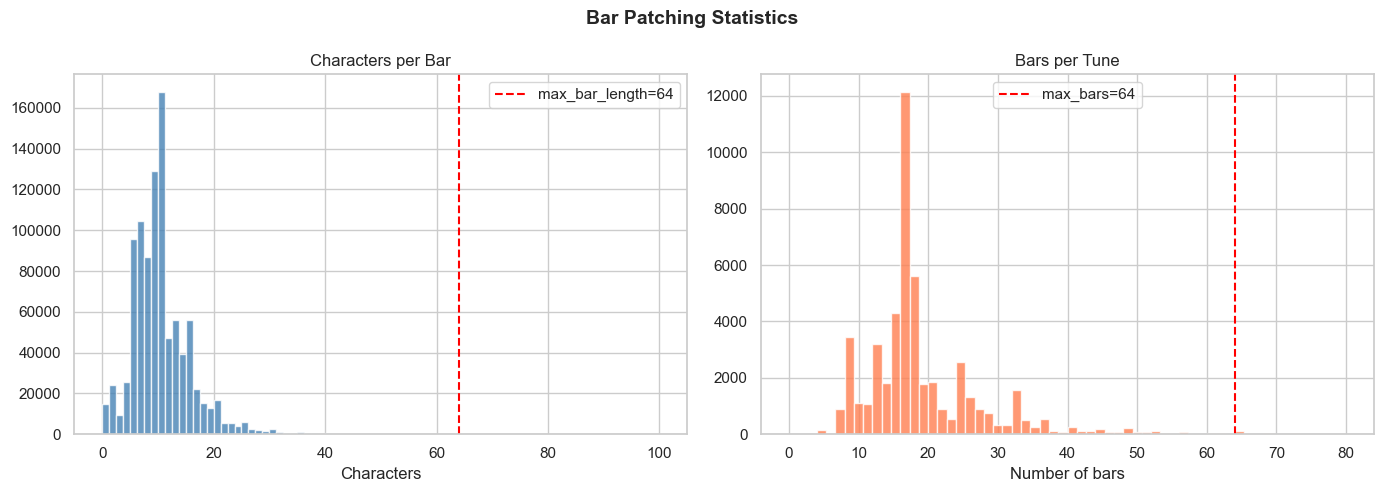

In [6]:
# ─── Bar length statistics ───
print("Computing bar length statistics across corpus...")
bar_lengths_all = []
bars_per_tune = []

for idx in tqdm(range(min(50000, len(train_df))), desc="Scanning bars"):
    body = train_df.iloc[idx]['abc_body']
    bars = patchifier.split_into_bars(body)
    bars_per_tune.append(len(bars))
    for bar in bars:
        bar_lengths_all.append(len(bar))

print(f"\nBar length stats (chars per bar):")
print(f"  Mean:   {np.mean(bar_lengths_all):.1f}")
print(f"  Median: {np.median(bar_lengths_all):.0f}")
print(f"  95th percentile: {np.percentile(bar_lengths_all, 95):.0f}")
print(f"  99th percentile: {np.percentile(bar_lengths_all, 99):.0f}")
print(f"  Max:    {np.max(bar_lengths_all)}")

print(f"\nBars per tune:")
print(f"  Mean:   {np.mean(bars_per_tune):.1f}")
print(f"  Median: {np.median(bars_per_tune):.0f}")
print(f"  95th percentile: {np.percentile(bars_per_tune, 95):.0f}")
print(f"  Max:    {np.max(bars_per_tune)}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(bar_lengths_all, bins=80, color='steelblue', edgecolor='white', alpha=0.8,
             range=(0, 100))
axes[0].axvline(64, color='red', linestyle='--', label='max_bar_length=64')
axes[0].set_title('Characters per Bar')
axes[0].set_xlabel('Characters')
axes[0].legend()

axes[1].hist(bars_per_tune, bins=60, color='coral', edgecolor='white', alpha=0.8,
             range=(0, 80))
axes[1].axvline(64, color='red', linestyle='--', label='max_bars=64')
axes[1].set_title('Bars per Tune')
axes[1].set_xlabel('Number of bars')
axes[1].legend()

plt.suptitle('Bar Patching Statistics', fontsize=14, fontweight='bold')
plt.tight_layout()
Path(PROJECT_DIR / 'figures').mkdir(exist_ok=True)
plt.savefig(PROJECT_DIR / 'figures' / 'bar_patching_stats.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.3 Patch Embedding Layer

Linear projection: each bar patch (max_bar_length character indices) → d_model embedding vector.
This is the first layer of the ABC2Vec encoder.

In [7]:
class PatchEmbedding(nn.Module):
    """
    Embeds bar patches into dense vectors.
    
    Steps:
    1. Character embedding: each char index → d_char vector
    2. Aggregate characters within a bar: mean pooling over non-pad chars
    3. Linear projection to d_model
    """
    
    def __init__(self, vocab_size: int, d_char: int = 64, d_model: int = 256,
                 max_bar_length: int = 64, max_bars: int = 64, pad_idx: int = 0):
        super().__init__()
        self.d_char = d_char
        self.d_model = d_model
        self.max_bar_length = max_bar_length
        self.max_bars = max_bars
        
        # Character-level embedding
        self.char_embed = nn.Embedding(vocab_size, d_char, padding_idx=pad_idx)
        
        # Projection from aggregated char embeddings to model dimension
        self.projection = nn.Linear(d_char, d_model)
        
        # Positional embedding for bar positions
        self.pos_embed = nn.Embedding(max_bars + 1, d_model)  # +1 for [CLS]
        
        # Layer norm
        self.layer_norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(0.1)
    
    def forward(self, bar_indices: torch.Tensor, char_mask: torch.Tensor,
                bar_mask: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Args:
            bar_indices: (batch, max_bars, max_bar_length) - character indices per bar
            char_mask: (batch, max_bars, max_bar_length) - True for real characters
            bar_mask: (batch, max_bars) - True for real bars
        
        Returns:
            embeddings: (batch, max_bars, d_model) - bar-level embeddings
            attention_mask: (batch, max_bars) - same as bar_mask
        """
        batch_size = bar_indices.shape[0]
        
        # Char embedding: (batch, max_bars, max_bar_length, d_char)
        char_embeds = self.char_embed(bar_indices)
        
        # Mean-pool characters within each bar (mask out padding)
        # char_mask: (batch, max_bars, max_bar_length) → expand for d_char
        mask_expanded = char_mask.unsqueeze(-1).float()  # (batch, max_bars, max_bar_length, 1)
        char_embeds_masked = char_embeds * mask_expanded
        
        # Sum and divide by count of real characters
        char_sum = char_embeds_masked.sum(dim=2)  # (batch, max_bars, d_char)
        char_count = char_mask.sum(dim=2, keepdim=True).float().clamp(min=1)  # (batch, max_bars, 1)
        bar_embeds = char_sum / char_count  # (batch, max_bars, d_char)
        
        # Project to model dimension
        bar_embeds = self.projection(bar_embeds)  # (batch, max_bars, d_model)
        
        # Add positional embeddings
        positions = torch.arange(self.max_bars, device=bar_indices.device).unsqueeze(0)
        bar_embeds = bar_embeds + self.pos_embed(positions)
        
        # Layer norm + dropout
        bar_embeds = self.layer_norm(bar_embeds)
        bar_embeds = self.dropout(bar_embeds)
        
        return bar_embeds, bar_mask

# Test the patch embedding
patch_embed = PatchEmbedding(
    vocab_size=vocab.size,
    d_char=64,
    d_model=256,
    max_bar_length=64,
    max_bars=64,
    pad_idx=vocab.pad_idx
)

# Create a small batch
sample_patches = patchifier.patchify(train_df.iloc[0]['abc_body'])
batch_bar_indices = sample_patches['bar_indices'].unsqueeze(0)  # (1, 64, 64)
batch_char_mask = sample_patches['char_mask'].unsqueeze(0)      # (1, 64, 64)
batch_bar_mask = sample_patches['bar_mask'].unsqueeze(0)        # (1, 64)

with torch.no_grad():
    embeds, mask = patch_embed(batch_bar_indices, batch_char_mask, batch_bar_mask)

print(f"Input bar_indices shape:  {batch_bar_indices.shape}")
print(f"Output embeddings shape:  {embeds.shape}")
print(f"Output mask shape:        {mask.shape}")
print(f"Active bars:              {mask.sum().item()}")
print(f"Embedding norm (bar 0):   {embeds[0, 0].norm():.3f}")

Input bar_indices shape:  torch.Size([1, 64, 64])
Output embeddings shape:  torch.Size([1, 64, 256])
Output mask shape:        torch.Size([1, 64])
Active bars:              16
Embedding norm (bar 0):   17.286


## 2.4 ABC Transposition Utility

Transpose ABC tunes by semitones. Critical for the **Transposition Invariance** pre-training objective.
The same reel in D major and G major should produce similar embeddings.

In [8]:
class ABCTransposer:
    """
    Transpose ABC notation tunes by a given number of semitones.
    Handles notes (A-G, a-g), accidentals (^, _, =), and key signatures.
    """
    
    # Chromatic scale (using sharps)
    CHROMATIC_SHARP = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
    CHROMATIC_FLAT = ['C', 'Db', 'D', 'Eb', 'E', 'F', 'Gb', 'G', 'Ab', 'A', 'Bb', 'B']
    
    # ABC note names to chromatic index
    NOTE_TO_SEMITONE = {
        'C': 0, 'D': 2, 'E': 4, 'F': 5, 'G': 7, 'A': 9, 'B': 11
    }
    
    # Key roots to semitone
    KEY_TO_SEMITONE = {
        'C': 0, 'C#': 1, 'Db': 1, 'D': 2, 'D#': 3, 'Eb': 3,
        'E': 4, 'F': 5, 'F#': 6, 'Gb': 6, 'G': 7, 'G#': 8,
        'Ab': 8, 'A': 9, 'A#': 10, 'Bb': 10, 'B': 11
    }
    
    @classmethod
    def transpose_note(cls, note_char: str, accidental: str, semitones: int) -> tuple[str, str]:
        """
        Transpose a single note by semitones.
        Returns (new_note, new_accidental).
        """
        base = note_char.upper()
        if base not in cls.NOTE_TO_SEMITONE:
            return note_char, accidental
        
        # Compute current semitone
        current = cls.NOTE_TO_SEMITONE[base]
        if accidental == '^':   # sharp
            current += 1
        elif accidental == '_':  # flat
            current -= 1
        
        # Transpose
        new_semitone = (current + semitones) % 12
        
        # Find the closest natural note
        sharp_name = cls.CHROMATIC_SHARP[new_semitone]
        
        if len(sharp_name) == 1:
            new_note = sharp_name
            new_acc = ''
        elif '#' in sharp_name:
            new_note = sharp_name[0]
            new_acc = '^'
        else:
            new_note = sharp_name[0]
            new_acc = '_'
        
        # Preserve case (lowercase = upper octave in ABC)
        if note_char.islower():
            new_note = new_note.lower()
        
        return new_note, new_acc
    
    @classmethod
    def transpose_key(cls, key_str: str, semitones: int) -> str:
        """
        Transpose a key signature string (e.g., 'D' → +5 → 'G', 'Ador' → +5 → 'Ddor').
        """
        # Parse key
        match = re.match(r'^([A-G][#b]?)(.*)$', key_str.strip())
        if not match:
            return key_str
        
        root = match.group(1)
        mode = match.group(2)
        
        # Transpose root
        if root in cls.KEY_TO_SEMITONE:
            new_semitone = (cls.KEY_TO_SEMITONE[root] + semitones) % 12
            new_root = cls.CHROMATIC_SHARP[new_semitone]
            # Convert sharp notation to ABC notation
            if '#' in new_root:
                new_root = new_root[0] + '#'
            return new_root + mode
        return key_str
    
    @classmethod
    def transpose_abc_body(cls, abc_body: str, semitones: int) -> str:
        """
        Transpose all notes in an ABC body by semitones.
        Handles ABC-specific notation: ^C (sharp), _B (flat), =F (natural).
        """
        if semitones == 0:
            return abc_body
        
        result = []
        i = 0
        while i < len(abc_body):
            ch = abc_body[i]
            
            # Check for accidental prefix
            if ch in '^_=' and i + 1 < len(abc_body) and abc_body[i + 1].upper() in 'ABCDEFG':
                accidental = ch if ch != '=' else ''
                note = abc_body[i + 1]
                new_note, new_acc = cls.transpose_note(note, accidental, semitones)
                if new_acc:
                    result.append(new_acc)
                result.append(new_note)
                i += 2
            elif ch.upper() in 'ABCDEFG':
                # Regular note without accidental
                new_note, new_acc = cls.transpose_note(ch, '', semitones)
                if new_acc:
                    result.append(new_acc)
                result.append(new_note)
                i += 1
            else:
                result.append(ch)
                i += 1
        
        return ''.join(result)

# Test transposition
transposer = ABCTransposer()

test_body = "D2 EF | G2 AB | c2 dc | BAGF |"
print(f"Original (D major):  {test_body}")
for semitones in [5, 7, -2, 12]:
    transposed = transposer.transpose_abc_body(test_body, semitones)
    new_key = transposer.transpose_key('D', semitones)
    print(f"  +{semitones:>2} semitones ({new_key}): {transposed}")

# Test key transposition
print(f"\nKey transpositions:")
for key in ['D', 'G', 'Ador', 'Gmix', 'Em']:
    for st in [2, 5, 7]:
        print(f"  {key} + {st} → {transposer.transpose_key(key, st)}")

Original (D major):  D2 EF | G2 AB | c2 dc | BAGF |
  + 5 semitones (G): G2 A^A | C2 DE | f2 gf | EDC^A |
  + 7 semitones (A): A2 BC | D2 E^F | g2 ag | ^FEDC |
  +-2 semitones (C): C2 D^D | F2 GA | ^a2 c^a | AGF^D |
  +12 semitones (D): D2 EF | G2 AB | c2 dc | BAGF |

Key transpositions:
  D + 2 → E
  D + 5 → G
  D + 7 → A
  G + 2 → A
  G + 5 → C
  G + 7 → D
  Ador + 2 → Bdor
  Ador + 5 → Ddor
  Ador + 7 → Edor
  Gmix + 2 → Amix
  Gmix + 5 → Cmix
  Gmix + 7 → Dmix
  Em + 2 → F#m
  Em + 5 → Am
  Em + 7 → Bm


In [9]:
# ─── Full transposition test on a real tune ───
real_body = train_df.iloc[0]['abc_body']
real_key = train_df.iloc[0]['key']

print(f"Original tune (key={real_key}):")
print(f"  {real_body[:150]}")

# Transpose up a perfect fifth (+7 semitones)
transposed_body = transposer.transpose_abc_body(real_body, 7)
transposed_key = transposer.transpose_key(real_key, 7)
print(f"\nTransposed +7 (key={transposed_key}):")
print(f"  {transposed_body[:150]}")

# Verify roundtrip: +7 then -7 should give back original
roundtrip = transposer.transpose_abc_body(transposed_body, -7)
print(f"\nRoundtrip match: {roundtrip == real_body}")

Original tune (key=D):
  A3 B ADFA | BAFA EGFE | DA, A,2 DFAF | GBAG FD D2 | A3 B ADFA | BAFA EGFE | DB, B,2 A,2 dB | AFEG FD D2 :| d3 f af f2 | afbf afef | d2 fd Adfa | bfaf 

Transposed +7 (key=A):
  E3 ^F EACE | ^FECE BDCB | AE, E,2 ACEC | D^FED CA A2 | E3 ^F EACE | ^FECE BDCB | A^F, ^F,2 E,2 a^F | ECBD CA A2 :| a3 c ec c2 | ec^fc ecbc | a2 ca Eac

Roundtrip match: True


## 2.5 Dataset Class for PyTorch DataLoader

Wraps the patchifier and transposer into a PyTorch Dataset for training.

In [10]:
from torch.utils.data import Dataset, DataLoader

class ABC2VecDataset(Dataset):
    """
    PyTorch Dataset for ABC2Vec pre-training.
    
    Returns bar-patched tune data with optional transposition augmentation.
    """
    
    def __init__(self, df: pd.DataFrame, patchifier: BarPatchifier,
                 augment_transpose: bool = True, body_col: str = 'abc_body',
                 key_col: str = 'key'):
        self.df = df.reset_index(drop=True)
        self.patchifier = patchifier
        self.augment_transpose = augment_transpose
        self.body_col = body_col
        self.key_col = key_col
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        abc_body = row[self.body_col]
        
        # Patchify original tune
        patches = self.patchifier.patchify(abc_body)
        
        item = {
            'bar_indices': patches['bar_indices'],
            'char_mask': patches['char_mask'],
            'bar_mask': patches['bar_mask'],
            'num_bars': patches['num_bars'],
        }
        
        # Optional: create a transposed version for contrastive learning
        if self.augment_transpose:
            semitones = np.random.choice([-5, -4, -3, -2, -1, 1, 2, 3, 4, 5, 6, 7])
            transposed_body = ABCTransposer.transpose_abc_body(abc_body, semitones)
            trans_patches = self.patchifier.patchify(transposed_body)
            item['trans_bar_indices'] = trans_patches['bar_indices']
            item['trans_char_mask'] = trans_patches['char_mask']
            item['trans_bar_mask'] = trans_patches['bar_mask']
        
        return item

# Test dataset
test_dataset = ABC2VecDataset(train_df.head(100), patchifier, augment_transpose=True)
sample = test_dataset[0]

print("Dataset sample:")
for k, v in sample.items():
    if isinstance(v, torch.Tensor):
        print(f"  {k}: {v.shape} ({v.dtype})")
    else:
        print(f"  {k}: {v}")

# Test DataLoader
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=True)
batch = next(iter(test_loader))
print(f"\nBatch shapes:")
for k, v in batch.items():
    if isinstance(v, torch.Tensor):
        print(f"  {k}: {v.shape}")

Dataset sample:
  bar_indices: torch.Size([64, 64]) (torch.int64)
  char_mask: torch.Size([64, 64]) (torch.bool)
  bar_mask: torch.Size([64]) (torch.bool)
  num_bars: 16
  trans_bar_indices: torch.Size([64, 64]) (torch.int64)
  trans_char_mask: torch.Size([64, 64]) (torch.bool)
  trans_bar_mask: torch.Size([64]) (torch.bool)

Batch shapes:
  bar_indices: torch.Size([4, 64, 64])
  char_mask: torch.Size([4, 64, 64])
  bar_mask: torch.Size([4, 64])
  num_bars: torch.Size([4])
  trans_bar_indices: torch.Size([4, 64, 64])
  trans_char_mask: torch.Size([4, 64, 64])
  trans_bar_mask: torch.Size([4, 64])


## 2.6 Section-Pair Dataset for Section Contrastive Loss

In [11]:
class SectionPairDataset(Dataset):
    """
    Dataset that yields (section_A, section_B) pairs from the same tune.
    Used for the Section Contrastive Loss (SCL) objective.
    """
    
    def __init__(self, section_pairs_path: str, patchifier: BarPatchifier):
        with open(section_pairs_path) as f:
            self.pairs = json.load(f)
        self.patchifier = patchifier
    
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        pair = self.pairs[idx]
        
        # Patchify section A
        patch_a = self.patchifier.patchify(pair['section_a'])
        # Patchify section B
        patch_b = self.patchifier.patchify(pair['section_b'])
        
        return {
            'a_bar_indices': patch_a['bar_indices'],
            'a_char_mask': patch_a['char_mask'],
            'a_bar_mask': patch_a['bar_mask'],
            'b_bar_indices': patch_b['bar_indices'],
            'b_char_mask': patch_b['char_mask'],
            'b_bar_mask': patch_b['bar_mask'],
            'tune_id': pair['tune_id']
        }

# Test section pair dataset
sp_dataset = SectionPairDataset(PROCESSED_DIR / 'section_pairs.json', patchifier)
print(f"Section pair dataset: {len(sp_dataset):,} pairs")

sp_sample = sp_dataset[0]
print(f"\nSample pair:")
for k, v in sp_sample.items():
    if isinstance(v, torch.Tensor):
        print(f"  {k}: {v.shape}")
    else:
        print(f"  {k}: {v}")

Section pair dataset: 302,005 pairs

Sample pair:
  a_bar_indices: torch.Size([64, 64])
  a_char_mask: torch.Size([64, 64])
  a_bar_mask: torch.Size([64])
  b_bar_indices: torch.Size([64, 64])
  b_char_mask: torch.Size([64, 64])
  b_bar_mask: torch.Size([64])
  tune_id: train_000000


## 2.7 Save Tokenizer & Patchifier Module

Export as a Python module for use in other notebooks.

In [12]:
# Save the tokenizer/patchifier config
tokenizer_config = {
    'vocab_size': vocab.size,
    'max_bar_length': 64,
    'max_bars': 64,
    'd_char': 64,
    'd_model': 256,
    'pad_idx': vocab.pad_idx,
    'mask_idx': vocab.mask_idx,
    'cls_idx': vocab.cls_idx,
    'sep_idx': vocab.sep_idx,
}

config_path = PROCESSED_DIR / 'tokenizer_config.json'
with open(config_path, 'w') as f:
    json.dump(tokenizer_config, f, indent=2)

print(f"Tokenizer config saved: {config_path}")
print(json.dumps(tokenizer_config, indent=2))

Tokenizer config saved: /Volumes/LLModels/ABC2VEC/data/processed/tokenizer_config.json
{
  "vocab_size": 98,
  "max_bar_length": 64,
  "max_bars": 64,
  "d_char": 64,
  "d_model": 256,
  "pad_idx": 0,
  "mask_idx": 4,
  "cls_idx": 2,
  "sep_idx": 3
}


In [13]:
# ─── Export as Python module ───
module_dir = PROJECT_DIR / 'abc2vec'
module_dir.mkdir(exist_ok=True)

# Write __init__.py
init_path = module_dir / '__init__.py'
init_path.write_text('# ABC2Vec package\n')

# Write tokenizer module
tokenizer_code = '''
"""ABC Tokenizer and Bar Patchifier for ABC2Vec."""

import re, json, collections
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset


class ABCVocabulary:
    SPECIAL_TOKENS = ["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]"]

    def __init__(self):
        self.char2idx = {}
        self.idx2char = {}
        self.char_freq = collections.Counter()
        for i, tok in enumerate(self.SPECIAL_TOKENS):
            self.char2idx[tok] = i
            self.idx2char[i] = tok

    def build_from_corpus(self, texts, min_freq=1):
        for text in texts:
            for ch in text:
                self.char_freq[ch] += 1
        idx = len(self.SPECIAL_TOKENS)
        for ch, freq in sorted(self.char_freq.items()):
            if freq >= min_freq and ch not in self.char2idx:
                self.char2idx[ch] = idx
                self.idx2char[idx] = ch
                idx += 1

    def encode(self, text):
        unk = self.char2idx["[UNK]"]
        return [self.char2idx.get(ch, unk) for ch in text]

    def decode(self, indices):
        return "".join(self.idx2char.get(i, "?") for i in indices
                       if self.idx2char.get(i, "") not in self.SPECIAL_TOKENS)

    @property
    def size(self):
        return len(self.char2idx)

    @property
    def pad_idx(self):
        return self.char2idx["[PAD]"]

    @property
    def mask_idx(self):
        return self.char2idx["[MASK]"]

    @property
    def cls_idx(self):
        return self.char2idx["[CLS]"]

    @property
    def sep_idx(self):
        return self.char2idx["[SEP]"]

    def save(self, path):
        with open(path, "w") as f:
            json.dump({"char2idx": self.char2idx, "char_freq": dict(self.char_freq)}, f, indent=2)

    @classmethod
    def load(cls, path):
        vocab = cls()
        with open(path) as f:
            data = json.load(f)
        vocab.char2idx = data["char2idx"]
        vocab.idx2char = {int(v): k for k, v in vocab.char2idx.items()}
        vocab.char_freq = collections.Counter(data.get("char_freq", {}))
        return vocab


class BarPatchifier:
    def __init__(self, vocab, max_bar_length=64, max_bars=64):
        self.vocab = vocab
        self.max_bar_length = max_bar_length
        self.max_bars = max_bars

    def split_into_bars(self, abc_body):
        body = abc_body.strip()
        bars = []
        current_bar = []
        i = 0
        while i < len(body):
            ch = body[i]
            if ch == "|":
                bar_str = "".join(current_bar).strip()
                if bar_str:
                    bars.append(bar_str)
                current_bar = []
                if i + 1 < len(body) and body[i + 1] in ":|]":
                    i += 2
                    continue
            elif ch == ":" and i + 1 < len(body) and body[i + 1] == "|":
                bar_str = "".join(current_bar).strip()
                if bar_str:
                    bars.append(bar_str)
                current_bar = []
                i += 2
                continue
            else:
                current_bar.append(ch)
            i += 1
        bar_str = "".join(current_bar).strip()
        if bar_str:
            bars.append(bar_str)
        return bars

    def patchify(self, abc_body):
        bars = self.split_into_bars(abc_body)[:self.max_bars]
        num_bars = len(bars)
        bar_indices = torch.full((self.max_bars, self.max_bar_length), self.vocab.pad_idx, dtype=torch.long)
        char_mask = torch.zeros(self.max_bars, self.max_bar_length, dtype=torch.bool)
        bar_mask = torch.zeros(self.max_bars, dtype=torch.bool)
        for i, bar in enumerate(bars):
            encoded = self.vocab.encode(bar)[:self.max_bar_length]
            bar_indices[i, :len(encoded)] = torch.tensor(encoded, dtype=torch.long)
            char_mask[i, :len(encoded)] = True
            bar_mask[i] = True
        return {"bar_indices": bar_indices, "bar_mask": bar_mask, "char_mask": char_mask,
                "num_bars": num_bars, "bars": bars}


class ABCTransposer:
    CHROMATIC_SHARP = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]
    NOTE_TO_SEMITONE = {"C": 0, "D": 2, "E": 4, "F": 5, "G": 7, "A": 9, "B": 11}
    KEY_TO_SEMITONE = {
        "C": 0, "C#": 1, "Db": 1, "D": 2, "D#": 3, "Eb": 3,
        "E": 4, "F": 5, "F#": 6, "Gb": 6, "G": 7, "G#": 8,
        "Ab": 8, "A": 9, "A#": 10, "Bb": 10, "B": 11
    }

    @classmethod
    def transpose_note(cls, note_char, accidental, semitones):
        base = note_char.upper()
        if base not in cls.NOTE_TO_SEMITONE:
            return note_char, accidental
        current = cls.NOTE_TO_SEMITONE[base]
        if accidental == "^":
            current += 1
        elif accidental == "_":
            current -= 1
        new_semitone = (current + semitones) % 12
        sharp_name = cls.CHROMATIC_SHARP[new_semitone]
        if len(sharp_name) == 1:
            new_note, new_acc = sharp_name, ""
        else:
            new_note, new_acc = sharp_name[0], "^"
        if note_char.islower():
            new_note = new_note.lower()
        return new_note, new_acc

    @classmethod
    def transpose_key(cls, key_str, semitones):
        match = re.match(r"^([A-G][#b]?)(.*)$", key_str.strip())
        if not match:
            return key_str
        root, mode = match.group(1), match.group(2)
        if root in cls.KEY_TO_SEMITONE:
            new_semitone = (cls.KEY_TO_SEMITONE[root] + semitones) % 12
            new_root = cls.CHROMATIC_SHARP[new_semitone]
            return new_root + mode
        return key_str

    @classmethod
    def transpose_abc_body(cls, abc_body, semitones):
        if semitones == 0:
            return abc_body
        result = []
        i = 0
        while i < len(abc_body):
            ch = abc_body[i]
            if ch in "^_=" and i + 1 < len(abc_body) and abc_body[i + 1].upper() in "ABCDEFG":
                accidental = ch if ch != "=" else ""
                note = abc_body[i + 1]
                new_note, new_acc = cls.transpose_note(note, accidental, semitones)
                if new_acc:
                    result.append(new_acc)
                result.append(new_note)
                i += 2
            elif ch.upper() in "ABCDEFG":
                new_note, new_acc = cls.transpose_note(ch, "", semitones)
                if new_acc:
                    result.append(new_acc)
                result.append(new_note)
                i += 1
            else:
                result.append(ch)
                i += 1
        return "".join(result)


class PatchEmbedding(nn.Module):
    def __init__(self, vocab_size, d_char=64, d_model=256, max_bar_length=64, max_bars=64, pad_idx=0):
        super().__init__()
        self.d_model = d_model
        self.char_embed = nn.Embedding(vocab_size, d_char, padding_idx=pad_idx)
        self.projection = nn.Linear(d_char, d_model)
        self.pos_embed = nn.Embedding(max_bars + 1, d_model)
        self.layer_norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(0.1)

    def forward(self, bar_indices, char_mask, bar_mask):
        char_embeds = self.char_embed(bar_indices)
        mask_expanded = char_mask.unsqueeze(-1).float()
        char_sum = (char_embeds * mask_expanded).sum(dim=2)
        char_count = char_mask.sum(dim=2, keepdim=True).float().clamp(min=1)
        bar_embeds = self.projection(char_sum / char_count)
        max_bars = bar_indices.shape[1]
        positions = torch.arange(max_bars, device=bar_indices.device).unsqueeze(0)
        bar_embeds = bar_embeds + self.pos_embed(positions)
        return self.layer_norm(self.dropout(bar_embeds)), bar_mask


class ABC2VecDataset(Dataset):
    def __init__(self, df, patchifier, augment_transpose=True, body_col="abc_body"):
        self.df = df.reset_index(drop=True)
        self.patchifier = patchifier
        self.augment_transpose = augment_transpose
        self.body_col = body_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        abc_body = self.df.iloc[idx][self.body_col]
        patches = self.patchifier.patchify(abc_body)
        item = {"bar_indices": patches["bar_indices"], "char_mask": patches["char_mask"],
                "bar_mask": patches["bar_mask"], "num_bars": patches["num_bars"]}
        if self.augment_transpose:
            semitones = np.random.choice([-5, -4, -3, -2, -1, 1, 2, 3, 4, 5, 6, 7])
            transposed = ABCTransposer.transpose_abc_body(abc_body, semitones)
            tp = self.patchifier.patchify(transposed)
            item["trans_bar_indices"] = tp["bar_indices"]
            item["trans_char_mask"] = tp["char_mask"]
            item["trans_bar_mask"] = tp["bar_mask"]
        return item


class SectionPairDataset(Dataset):
    def __init__(self, section_pairs_path, patchifier):
        with open(section_pairs_path) as f:
            self.pairs = json.load(f)
        self.patchifier = patchifier

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        pair = self.pairs[idx]
        pa = self.patchifier.patchify(pair["section_a"])
        pb = self.patchifier.patchify(pair["section_b"])
        return {"a_bar_indices": pa["bar_indices"], "a_char_mask": pa["char_mask"],
                "a_bar_mask": pa["bar_mask"], "b_bar_indices": pb["bar_indices"],
                "b_char_mask": pb["char_mask"], "b_bar_mask": pb["bar_mask"],
                "tune_id": pair["tune_id"]}
'''

tokenizer_module_path = module_dir / 'tokenizer.py'
tokenizer_module_path.write_text(tokenizer_code)
print(f"Tokenizer module saved to {tokenizer_module_path}")
print(f"\nModule contents:")
for f in sorted(module_dir.glob('*.py')):
    print(f"  {f.name}")

Tokenizer module saved to /Volumes/LLModels/ABC2VEC/abc2vec/tokenizer.py

Module contents:
  __init__.py
  tokenizer.py
